# CSE374 — Machine Learning Classification Project


**Dataset:** Credit Card Default (Taiwan)  
**Target:** `default.payment.next.month` — Binary (1 = defaulted, 0 = did not default)  
**Models:** Logistic Regression · Decision Tree · k-Nearest Neighbours  


---

| Section | Description |
|---------|-------------|
| 1 | Problem Framing & Data Understanding |
| 2 | Data Acquisition & Documentation |
| 4 | Data Cleaning & Preprocessing |
| 5 | Exploratory Data Analysis (EDA) |
| 6 | Modelling (LR · DT · kNN) |
| 7 | Performance Evaluation |
| 8 | Model Comparison |
| 9 | Error Analysis |
| 10 | AI Tool Usage & Reflection |


---
# Section 1: Problem Framing & Data Understanding

## What problem are we solving?
Banks need to assess credit risk before extending or renewing credit lines.  
Given a customer's demographic profile, credit history, and recent payment behaviour,  
can we **predict whether they will default on their next monthly payment**?

## Target Variable
- **Column:** `default.payment.next.month` (renamed to `default`)
- **Type:** Binary — 1 = defaulted, 0 = did not default

## Classification Type
**Binary classification** — two possible outcomes per prediction.

## Anticipated Challenges
| Challenge | Description |
|-----------|-------------|
| **Class imbalance** | ~22% default rate — naive accuracy is misleading |
| **Feature correlation** | Six months of bill/payment amounts are correlated across time |
| **Mixed feature types** | Categorical (SEX, EDUCATION, MARRIAGE) + continuous (amounts, AGE) |
| **Noisy categoricals** | Undocumented values in EDUCATION (0, 5, 6) and MARRIAGE (0) |


---
# Section 2: Data Acquisition & Documentation

**Source:** UCI Machine Learning Repository  
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients





---
## Environment Setup




In [1]:
pip install xlrd


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Load Dataset

> **Why `header=1`?** The raw XLS file has a metadata row at index 0.  
> Actual column names are in row 1. Without `header=1`, pandas uses the metadata row as headers.


In [2]:
import pandas as pd

df = pd.read_excel('default of credit card clients.xls', header=1)
print('Dataset loaded successfully.')


Dataset loaded successfully.


---
## Initial Inspection

Confirms the load was successful: expected 30,000 rows × 25 columns (24 features + 1 target).  
`df.info()` reveals all columns are `int64` with **zero nulls** so no imputation required.


In [3]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (30000, 25)
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [4]:
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

---
# Section 4: Data Cleaning & Preprocessing

> **Pipeline order:** Rename → Drop ID → Inspect categoricals → Clean → Verify  
> → Split X/y → Train/val/test split → Scale



### 4.1 Rename Target Column and Drop ID

- **Rename:** Spaces in column names require bracket notation everywhere so renaming once cleans all downstream code.
- **Drop ID:** Sequential row number with no predictive value. Keeping it causes data leakage.


In [6]:
df = df.rename(columns={'default payment next month': 'default'})
df = df.drop(columns=['ID'])

print('Shape after cleanup:', df.shape)  # Expected: (30000, 24)
print('Target column present:', 'default' in df.columns)


Shape after cleanup: (30000, 24)
Target column present: True


### 4.2 Inspect Categorical Columns

Before cleaning, we inspect actual value distributions to identify undocumented values  
and determine how rare they are before deciding how to handle them.


In [7]:
print('EDUCATION values:')
print(df['EDUCATION'].value_counts().sort_index())
print()
print('MARRIAGE values:')
print(df['MARRIAGE'].value_counts().sort_index())
print()
print('SEX values:')
print(df['SEX'].value_counts().sort_index())


EDUCATION values:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE values:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

SEX values:
SEX
1    11888
2    18112
Name: count, dtype: int64


### 4.3 Clean EDUCATION




In [8]:
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print('EDUCATION after cleaning:')
print(df['EDUCATION'].value_counts().sort_index())


EDUCATION after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


### 4.4 Clean MARRIAGE



In [9]:
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print('MARRIAGE after cleaning:')
print(df['MARRIAGE'].value_counts().sort_index())


MARRIAGE after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


### 4.5 Verify — No Unexpected Values Remain




In [ ]:
print('Unique EDUCATION:', sorted(df['EDUCATION'].unique()))  
print('Unique MARRIAGE: ', sorted(df['MARRIAGE'].unique()))  
print('Unique SEX:      ', sorted(df['SEX'].unique()))       



Unique EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique MARRIAGE:  [np.int64(1), np.int64(2), np.int64(3)]
Unique SEX:       [np.int64(1), np.int64(2)]


### 4.6 Separate Features (X) and Target (y)

All scikit-learn models expect separate X and y inputs.  
We print the class distribution to confirm the ~22% default rate that stratified splitting must preserve.


In [11]:
X = df.drop(columns=['default'])
y = df['default']

print('Class distribution:')
print(y.value_counts())
print(f'Default rate: {round(y.mean() * 100, 2)}%')


Class distribution:
default
0    23364
1     6636
Name: count, dtype: int64
Default rate: 22.12%


### 4.7 Train / Validation / Test Split (70% / 15% / 15%)

| Set | Purpose |
|-----|--------|
| **Train (70%)** |  Model learns patterns |
| **Validation (15%)** |  Hyperparameter tuning and model comparison |
| **Test (15%)** |  Final evaluation — touched once at the end |



In [ ]:
from sklearn.model_selection import train_test_split

# Split 1: carve out 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Split 2: carve 15% validation from remaining 85%

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f'Train size:      {X_train.shape}  | Default rate: {round(y_train.mean()*100,2)}%')
print(f'Validation size: {X_val.shape}  | Default rate: {round(y_val.mean()*100,2)}%')
print(f'Test size:       {X_test.shape}  | Default rate: {round(y_test.mean()*100,2)}%')


Train size:      (21012, 23)  | Default rate: 22.12%
Validation size: (4488, 23)  | Default rate: 22.13%
Test size:       (4500, 23)  | Default rate: 22.11%


### 4.8 Identify Columns to Scale






In [13]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
scale_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f'Columns to scale ({len(scale_cols)}):')
print(scale_cols)


Columns to scale (20):
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### 4.9 Apply StandardScaler — Fit on Training Data Only



In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

# FIT only on training, TRANSFORM all three sets
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print('Scaling complete.')
print('Training set column means (all should be ~0):')
print(X_train_scaled[scale_cols].mean().round(3))


Scaling complete.
Training set column means (all should be ~0):
LIMIT_BAL    0.0
AGE          0.0
PAY_0        0.0
PAY_2        0.0
PAY_3       -0.0
PAY_4       -0.0
PAY_5        0.0
PAY_6       -0.0
BILL_AMT1    0.0
BILL_AMT2   -0.0
BILL_AMT3    0.0
BILL_AMT4   -0.0
BILL_AMT5    0.0
BILL_AMT6   -0.0
PAY_AMT1     0.0
PAY_AMT2     0.0
PAY_AMT3     0.0
PAY_AMT4     0.0
PAY_AMT5    -0.0
PAY_AMT6    -0.0
dtype: float64


---
# Section 5: Exploratory Data Analysis (EDA)



### 5.0 Import Plotting Libraries


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


### Plot 1 — Class Distribution

**Interpretation:**  
The training set contains **16,364 non-default** and **4,648 default** cases (**22.1% default rate**).  


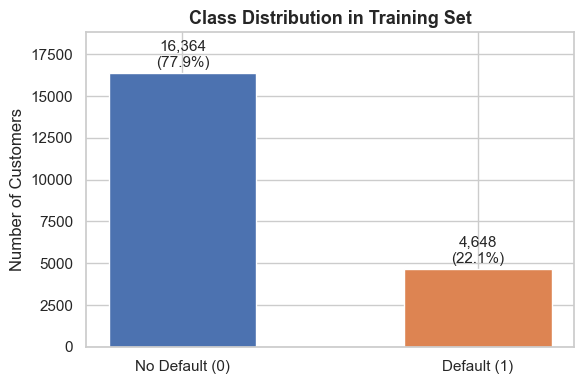

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = y_train.value_counts().sort_index()
bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({count/len(y_train)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


### Plot 2 — Default Rate by Most Recent Payment Status (PAY_0)

**PAY_0 values:** -2 = no consumption · -1 = paid on time · 0 = revolving credit · 1–8 = months delayed




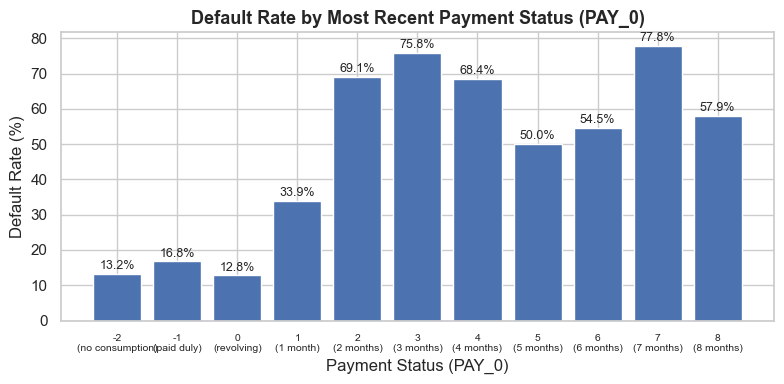

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

pay0_default = df.groupby('PAY_0')['default'].mean() * 100

bars = ax.bar(pay0_default.index, pay0_default.values,
              color='#4C72B0', edgecolor='white')

for bar, val in zip(bars, pay0_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Default Rate by Most Recent Payment Status (PAY_0)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Payment Status (PAY_0)')
ax.set_ylabel('Default Rate (%)')
ax.set_xticks(pay0_default.index)
ax.set_xticklabels([
    '-2\n(no consumption)', '-1\n(paid duly)', '0\n(revolving)',
    '1\n(1 month)', '2\n(2 months)', '3\n(3 months)',
    '4\n(4 months)', '5\n(5 months)', '6\n(6 months)',
    '7\n(7 months)', '8\n(8 months)'
], fontsize=7.5)
plt.tight_layout()
plt.show()


### Plot 3 — Default Rate by Credit Limit (LIMIT_BAL)



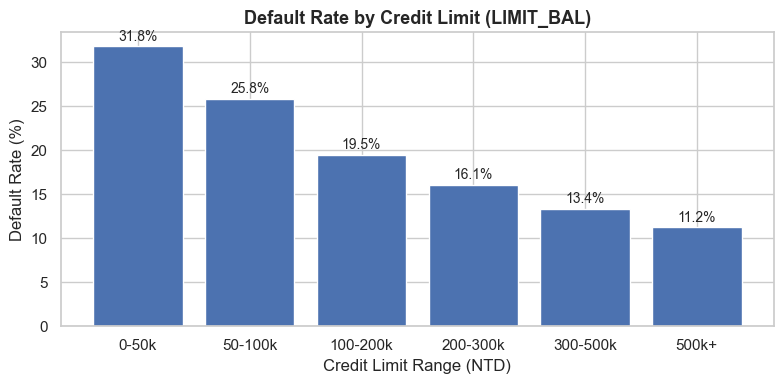

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

df['LIMIT_BAL_BIN'] = pd.cut(df['LIMIT_BAL'],
                              bins=[0, 50000, 100000, 200000, 300000, 500000, 800000],
                              labels=['0-50k', '50-100k', '100-200k',
                                      '200-300k', '300-500k', '500k+'])

limit_default = df.groupby('LIMIT_BAL_BIN', observed=True)['default'].mean() * 100

bars = ax.bar(limit_default.index, limit_default.values,
              color='#4C72B0', edgecolor='white')

for bar, val in zip(bars, limit_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Default Rate by Credit Limit (LIMIT_BAL)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Limit Range (NTD)')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()


### Plot 4 — Feature Correlation Heatmap



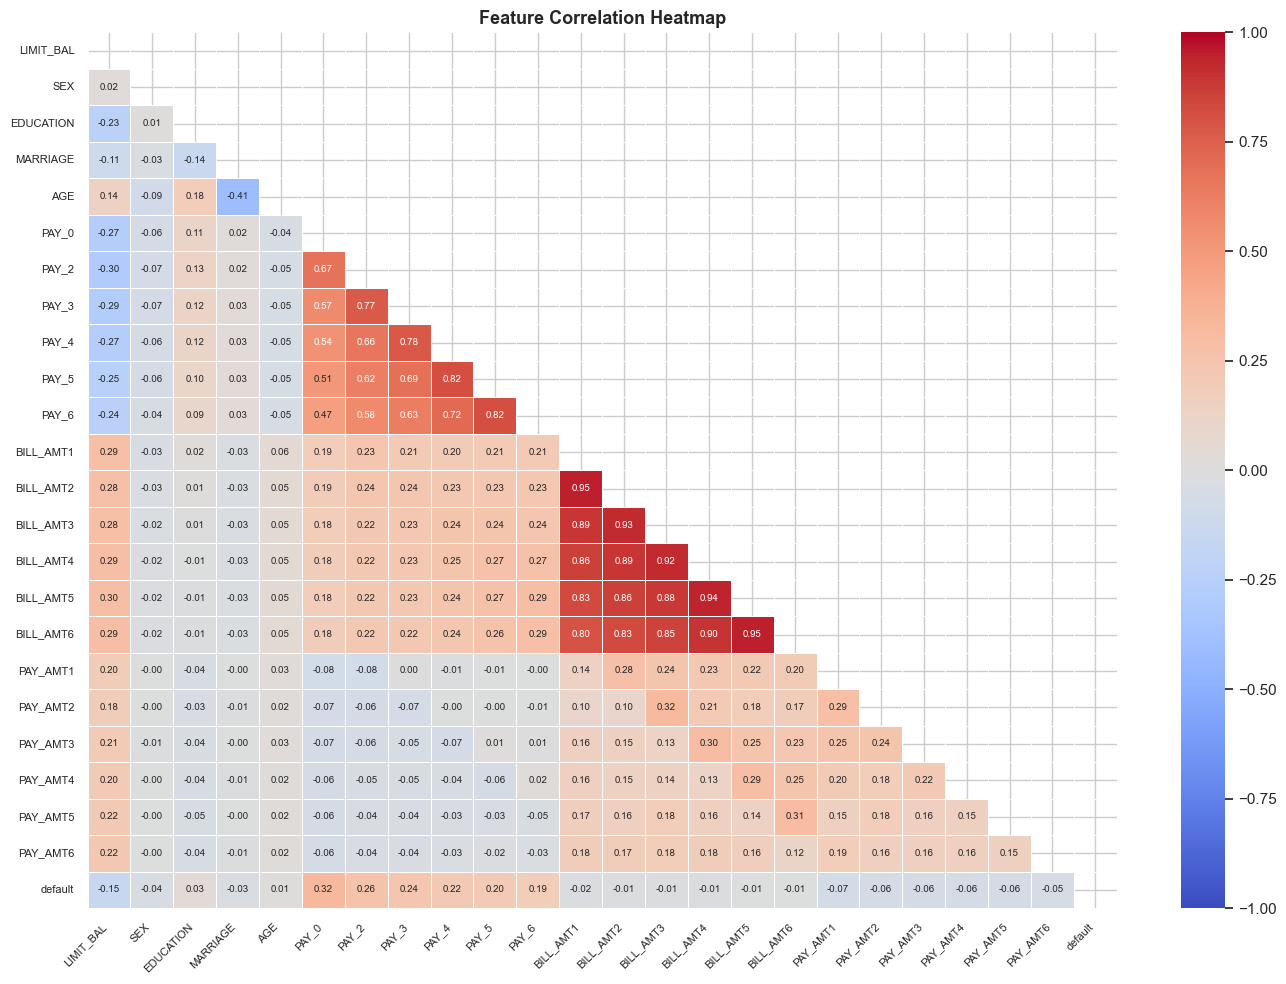

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df.drop(columns=['LIMIT_BAL_BIN']).corr()
mask = sns.utils.np.triu(sns.utils.np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, linewidths=0.5, ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


---
# Section 6: Modelling



---
## 6.1 Logistic Regression

**Design choices:**
- `class_weight='balanced'` :compensates for 22% class imbalance automatically
- `max_iter=1000` :default 100 iterations insufficient for convergence on 23 features
- Evaluated with `predict_proba()` for ROC-AUC (threshold-independent metric)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_val_scaled)
y_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

print('=== Logistic Regression — Validation Results ===')
print(f'Accuracy:  {accuracy_score(y_val, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_lr):.4f}')


=== Logistic Regression — Validation Results ===
Accuracy:  0.7141
F1-Score:  0.4982
ROC-AUC:   0.7306


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


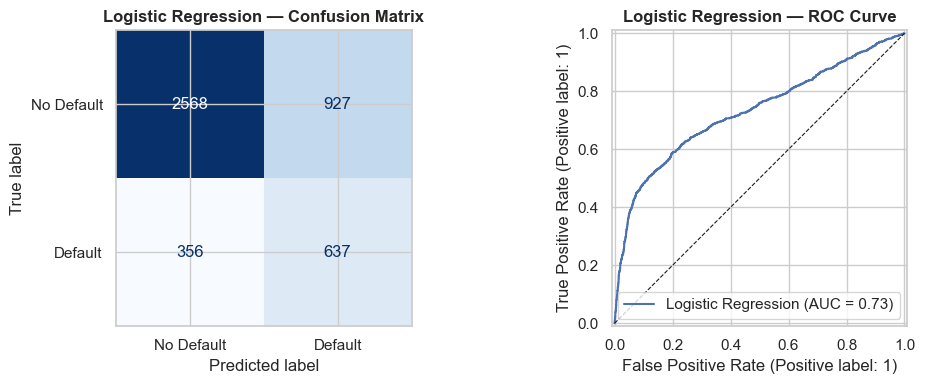

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_lr),
    display_labels=['No Default', 'Default']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(y_val, y_prob_lr, ax=axes[1],
    name='Logistic Regression', color='#4C72B0')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6.2 Decision Tree

### Baseline (No Tuning)
An untuned tree with no depth limit overfits by memorising training data.  


In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_baseline = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_baseline.fit(X_train_scaled, y_train)

y_pred_dt_base = dt_baseline.predict(X_val_scaled)
y_prob_dt_base = dt_baseline.predict_proba(X_val_scaled)[:, 1]

print('=== Decision Tree (Baseline — No Tuning) ===')
print(f'Accuracy:  {accuracy_score(y_val, y_pred_dt_base):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_pred_dt_base):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_dt_base):.4f}')


=== Decision Tree (Baseline — No Tuning) ===
Accuracy:  0.7389
F1-Score:  0.4116
ROC-AUC:   0.6222


### Hyperparameter Tuning with GridSearchCV

**Parameters tuned:**
- `max_depth` : limits levels of splits; prevents memorisation
- `min_samples_split` : minimum samples required to split a node
- `min_samples_leaf` :minimum samples required at each leaf




In [23]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
dt_grid.fit(X_train_scaled, y_train)

print('Best parameters:', dt_grid.best_params_)
print('Best cross-val ROC-AUC:', round(dt_grid.best_score_, 4))


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 50}
Best cross-val ROC-AUC: 0.7604


In [24]:
dt_tuned = dt_grid.best_estimator_

y_pred_dt = dt_tuned.predict(X_val_scaled)
y_prob_dt = dt_tuned.predict_proba(X_val_scaled)[:, 1]

print('=== Decision Tree (Tuned) — Validation Results ===')
print(f'Accuracy:  {accuracy_score(y_val, y_pred_dt):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_pred_dt):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_dt):.4f}')


=== Decision Tree (Tuned) — Validation Results ===
Accuracy:  0.7193
F1-Score:  0.5047
ROC-AUC:   0.7534


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


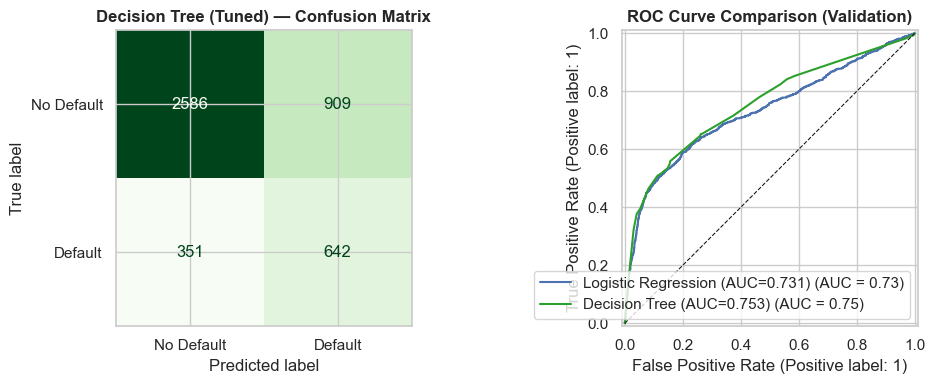

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_dt),
    display_labels=['No Default', 'Default']).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Decision Tree (Tuned) — Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(y_val, y_prob_lr, ax=axes[1],
    name='Logistic Regression (AUC=0.731)', color='#4C72B0')
RocCurveDisplay.from_predictions(y_val, y_prob_dt, ax=axes[1],
    name='Decision Tree (AUC=0.753)', color='#2CA02C')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('ROC Curve Comparison (Validation)', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6.3 k-Nearest Neighbours (kNN)

  
Imbalance is handled by tuning k (larger k reduces majority-class bias).



In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)

y_pred_knn_base = knn_baseline.predict(X_val_scaled)
y_prob_knn_base = knn_baseline.predict_proba(X_val_scaled)[:, 1]

print('=== kNN (Baseline — k=5) ===')
print(f'Accuracy:  {accuracy_score(y_val, y_pred_knn_base):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_pred_knn_base):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_knn_base):.4f}')


=== kNN (Baseline — k=5) ===
Accuracy:  0.7979
F1-Score:  0.4285
ROC-AUC:   0.7118


### Hyperparameter Tuning

**Parameters tuned:**
- `n_neighbors` : larger k smooths majority-class bias
- `weights` : uniform vs distance-weighted voting
- `metric` : Euclidean vs Manhattan distance




In [27]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
knn_grid.fit(X_train_scaled, y_train)

print('Best parameters:', knn_grid.best_params_)
print('Best cross-val ROC-AUC:', round(knn_grid.best_score_, 4))


Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'uniform'}
Best cross-val ROC-AUC: 0.7546


In [28]:
knn_tuned = knn_grid.best_estimator_

y_pred_knn = knn_tuned.predict(X_val_scaled)
y_prob_knn = knn_tuned.predict_proba(X_val_scaled)[:, 1]

print('=== kNN (Tuned) — Validation Results ===')
print(f'Accuracy:  {accuracy_score(y_val, y_pred_knn):.4f}')
print(f'F1-Score:  {f1_score(y_val, y_pred_knn):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_val, y_prob_knn):.4f}')


=== kNN (Tuned) — Validation Results ===
Accuracy:  0.8182
F1-Score:  0.4310
ROC-AUC:   0.7566


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


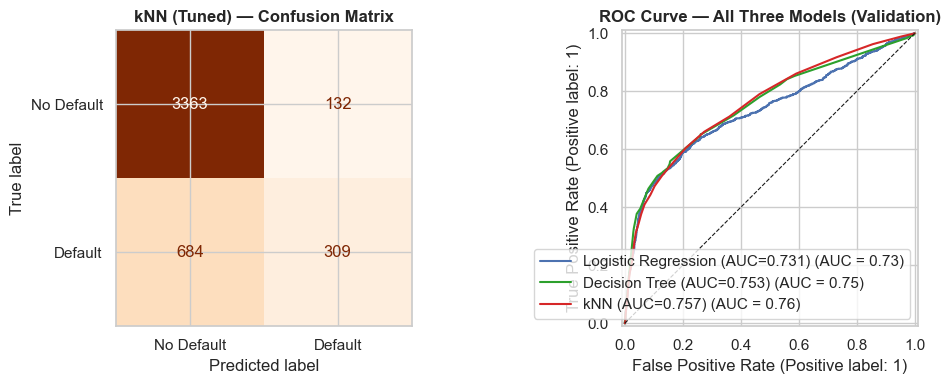

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_knn),
    display_labels=['No Default', 'Default']).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('kNN (Tuned) — Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(y_val, y_prob_lr, ax=axes[1],
    name='Logistic Regression (AUC=0.731)', color='#4C72B0')
RocCurveDisplay.from_predictions(y_val, y_prob_dt, ax=axes[1],
    name='Decision Tree (AUC=0.753)', color='#2CA02C')
RocCurveDisplay.from_predictions(y_val, y_prob_knn, ax=axes[1],
    name='kNN (AUC=0.757)', color='#D62728')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('ROC Curve — All Three Models (Validation)', fontweight='bold')

plt.tight_layout()
plt.show()


---
# Section 7: Performance Evaluation — Final Test Set




In [30]:
# Evaluate all three models on the held-out test set
y_pred_lr_test  = lr_model.predict(X_test_scaled)
y_prob_lr_test  = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_dt_test  = dt_tuned.predict(X_test_scaled)
y_prob_dt_test  = dt_tuned.predict_proba(X_test_scaled)[:, 1]

y_pred_knn_test = knn_tuned.predict(X_test_scaled)
y_prob_knn_test = knn_tuned.predict_proba(X_test_scaled)[:, 1]

import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (Tuned)', 'kNN (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_test),
        accuracy_score(y_test, y_pred_dt_test),
        accuracy_score(y_test, y_pred_knn_test)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_test),
        f1_score(y_test, y_pred_dt_test),
        f1_score(y_test, y_pred_knn_test)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr_test),
        roc_auc_score(y_test, y_prob_dt_test),
        roc_auc_score(y_test, y_prob_knn_test)
    ]
})

results[['Accuracy', 'F1-Score', 'ROC-AUC']] = results[['Accuracy', 'F1-Score', 'ROC-AUC']].round(4)
print('=== Final Test Set Results ===')
print(results.to_string(index=False))


=== Final Test Set Results ===
                Model  Accuracy  F1-Score  ROC-AUC
  Logistic Regression    0.6851    0.4679   0.7107
Decision Tree (Tuned)    0.7118    0.5085   0.7544
          kNN (Tuned)    0.8093    0.4123   0.7481


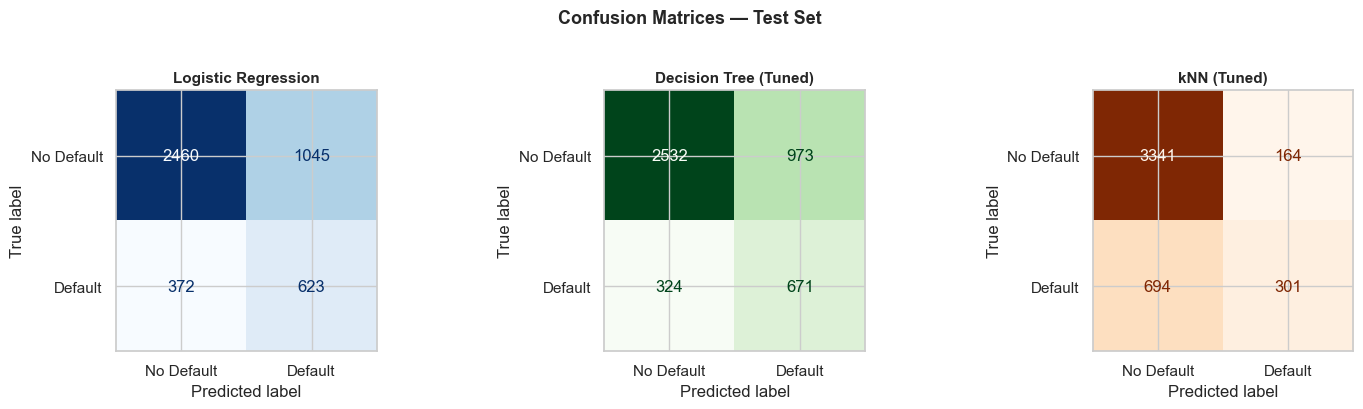

In [31]:
# Confusion matrices — all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds, cmap) in zip(axes, [
    ('Logistic Regression', y_pred_lr_test, 'Blues'),
    ('Decision Tree (Tuned)', y_pred_dt_test, 'Greens'),
    ('kNN (Tuned)', y_pred_knn_test, 'Oranges'),
]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
        display_labels=['No Default', 'Default']).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


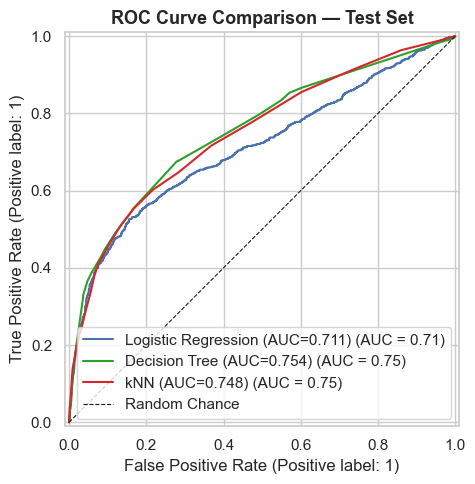

In [32]:
# Final ROC curve comparison — test set
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr_test, ax=ax,
    name='Logistic Regression (AUC=0.711)', color='#4C72B0')
RocCurveDisplay.from_predictions(y_test, y_prob_dt_test, ax=ax,
    name='Decision Tree (AUC=0.754)', color='#2CA02C')
RocCurveDisplay.from_predictions(y_test, y_prob_knn_test, ax=ax,
    name='kNN (AUC=0.748)', color='#D62728')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random Chance')
ax.set_title('ROC Curve Comparison — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
# Section 8: Model Comparison

| Model | Accuracy | F1-Score | ROC-AUC | Best At |
|-------|----------|----------|---------|--------|
| Logistic Regression | 0.6851 | 0.4679 | 0.7107 | — |
| **Decision Tree (Tuned)** | **0.7118** | **0.5085** | **0.7544** | **F1 + AUC (winner)** |
| kNN (Tuned) | 0.8093 | 0.4123 | 0.7481 | Accuracy (misleading) |






---
# Section 9: Error Analysis


In [33]:
# Build error analysis dataframe
error_df = X_test.copy()
error_df['actual']   = y_test.values
error_df['pred_lr']  = y_pred_lr_test
error_df['pred_dt']  = y_pred_dt_test
error_df['pred_knn'] = y_pred_knn_test

error_df['lr_wrong']  = (error_df['actual'] != error_df['pred_lr']).astype(int)
error_df['dt_wrong']  = (error_df['actual'] != error_df['pred_dt']).astype(int)
error_df['knn_wrong'] = (error_df['actual'] != error_df['pred_knn']).astype(int)

print('=== Misclassification Count (Test Set, n=4500) ===')
print(f'Logistic Regression: {error_df["lr_wrong"].sum()} ({error_df["lr_wrong"].mean()*100:.1f}%)')
print(f'Decision Tree:       {error_df["dt_wrong"].sum()} ({error_df["dt_wrong"].mean()*100:.1f}%)')
print(f'kNN:                 {error_df["knn_wrong"].sum()} ({error_df["knn_wrong"].mean()*100:.1f}%)')

print('\n=== Error Type Breakdown ===')
for name, pred in [('Logistic Regression', 'pred_lr'),
                    ('Decision Tree',       'pred_dt'),
                    ('kNN',                 'pred_knn')]:
    fn = ((error_df['actual'] == 1) & (error_df[pred] == 0)).sum()
    fp = ((error_df['actual'] == 0) & (error_df[pred] == 1)).sum()
    print(f'{name}:')
    print(f'  False Negatives (missed defaults): {fn}')
    print(f'  False Positives (false alarms):    {fp}')


=== Misclassification Count (Test Set, n=4500) ===
Logistic Regression: 1417 (31.5%)
Decision Tree:       1297 (28.8%)
kNN:                 858 (19.1%)

=== Error Type Breakdown ===
Logistic Regression:
  False Negatives (missed defaults): 372
  False Positives (false alarms):    1045
Decision Tree:
  False Negatives (missed defaults): 324
  False Positives (false alarms):    973
kNN:
  False Negatives (missed defaults): 694
  False Positives (false alarms):    164


In [34]:
# Profile of Decision Tree missed defaults vs caught defaults
fn_dt     = error_df[(error_df['actual'] == 1) & (error_df['pred_dt'] == 0)]
caught_dt = error_df[(error_df['actual'] == 1) & (error_df['pred_dt'] == 1)]

print('=== Decision Tree: Missed Defaults vs Caught Defaults ===')
print(f'{"Feature":<15} {"Missed (FN)":<15} {"Caught (TP)":<15}')
print('-' * 45)
for col in ['PAY_0', 'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']:
    print(f'{col:<15} {fn_dt[col].mean():<15.1f} {caught_dt[col].mean():<15.1f}')

print(f'\nMissed defaults: {len(fn_dt)}')
print(f'Caught defaults: {len(caught_dt)}')


=== Decision Tree: Missed Defaults vs Caught Defaults ===
Feature         Missed (FN)     Caught (TP)    
---------------------------------------------
PAY_0           -0.3            1.1            
LIMIT_BAL       160123.5        127943.4       
AGE             36.5            36.0           
BILL_AMT1       59681.5         45897.2        
PAY_AMT1        5015.2          2460.5         

Missed defaults: 324
Caught defaults: 671


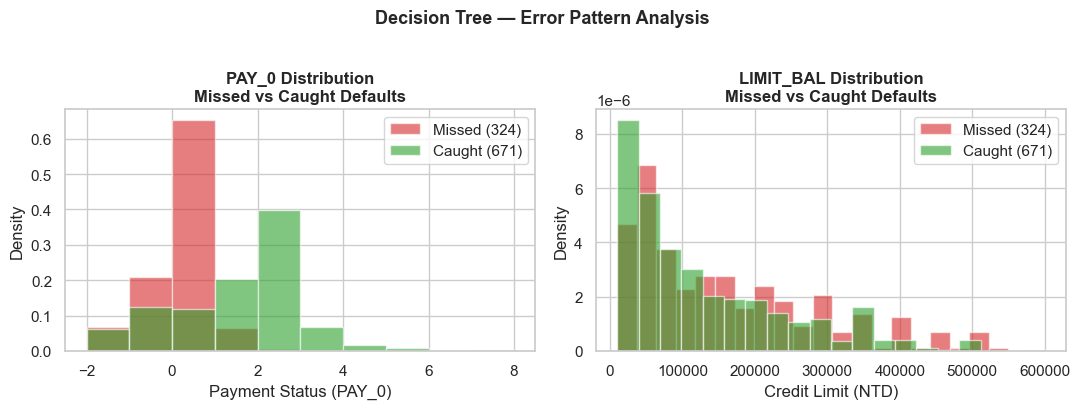

In [35]:
# Visualise error patterns
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(fn_dt['PAY_0'], bins=range(-2, 9), alpha=0.6,
             color='#D62728', label=f'Missed ({len(fn_dt)})', density=True)
axes[0].hist(caught_dt['PAY_0'], bins=range(-2, 9), alpha=0.6,
             color='#2CA02C', label=f'Caught ({len(caught_dt)})', density=True)
axes[0].set_title('PAY_0 Distribution\nMissed vs Caught Defaults', fontweight='bold')
axes[0].set_xlabel('Payment Status (PAY_0)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(fn_dt['LIMIT_BAL'], bins=20, alpha=0.6,
             color='#D62728', label=f'Missed ({len(fn_dt)})', density=True)
axes[1].hist(caught_dt['LIMIT_BAL'], bins=20, alpha=0.6,
             color='#2CA02C', label=f'Caught ({len(caught_dt)})', density=True)
axes[1].set_title('LIMIT_BAL Distribution\nMissed vs Caught Defaults', fontweight='bold')
axes[1].set_xlabel('Credit Limit (NTD)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Decision Tree — Error Pattern Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Error Analysis Summary

**Who does the Decision Tree miss?**  
Missed defaulters have PAY_0 ≈ -0.3 (recent on-time payments) vs caught defaulters at PAY_0 ≈ 1.1.  
They also have higher credit limits (160k vs 128k) and made larger recent payments (5,015 vs 2,460 NTD).  
These are customers who **appear financially healthy in the most recent month** but default the next .



---
# Section 10: AI Tool Usage & Reflection

## Overview
AI tools were used sparingly in this project : primarily to clarify unfamiliar
concepts and debug specific errors. All decisions, implementations, and interpretations
were made by the team. Every AI explanation was verified by running the code and
checking outputs manually.

---

## Example 1 — Understanding GridSearchCV
**Tool used:** Claude (Anthropic)

**Prompt:** "What is GridSearchCV and how does it work?"

**What was helpful:**
Understanding the concept helped us choose meaningful parameter ranges ourselves .
for example, we decided to test `max_depth` values of 3, 5, 7, 10, 15 based on
our understanding of how depth affects overfitting.

**How we verified:**
Ran GridSearchCV on our actual data and confirmed the best parameters made
intuitive sense .`max_depth=5` preventing overfitting was consistent with
the baseline vs tuned AUC improvement (0.622 → 0.754).

---

## Example 2 — Debugging a Code Error
**Tool used:** Claude (Anthropic)

**Error:** `ValueError: Found input variables with inconsistent numbers of samples: [25500, 30000]`

**Cause identified:** Second split used `stratify=y` (30,000 rows) instead of `stratify=y_temp` (25,500 rows).

**What was helpful:** Identified the exact line and parameter causing the error.


**How we verified:** Fixed `stratify=y` but `stratify=y_temp` and confirmed correct split sizes: 21,012 / 4,488 / 4,500.

---

## Example 3 — Clarifying Why Accuracy Was Misleading
**Tool used:** Claude (Anthropic)

**Prompt:** "kNN has the highest accuracy but lowest F1. Why is Decision Tree considered better here?"

**What was helpful:** Clarified the relationship between class imbalance and metric choice.

**How we verified:** Computed FN counts directly from our confusion matrix:
- kNN False Negatives: 694 (misses 70% of actual defaulters)
- Decision Tree False Negatives: 324 (misses 33% of actual defaulters)

---

